**Prompt Title:** Interactive COVID-19 City-Level Dashboard (Jupyter Notebook)

**Prompt:**

Create a fully functional and visually appealing Jupyter Notebook in Python that builds an **interactive dashboard for analyzing city-level COVID-19 data**. The notebook should be structured, well-commented, and suitable for academic submission as well as real-world data analysis.

### 🔹 Objectives:

* Analyze city-level COVID-19 dataset
* Build a modern, visually attractive, and interactive dashboard
* Use both static and interactive visualizations
* Ensure the notebook is clean, readable, and professional

---

### 🔹 Technical Requirements:

#### 1. Data Handling & Preprocessing

* Use **pandas** and **numpy** for:

  * Loading dataset (CSV format)
  * Handling missing values
  * Converting date columns to datetime
  * Aggregating data by city, date, and state
  * Creating new features (e.g., daily cases, growth rate)

---

#### 2. Advanced Static Visualizations (Seaborn & Matplotlib)

Use **advanced seaborn styling** (`darkgrid`, `whitegrid`, custom palettes) to create:

* 📊 Box Plot: Distribution of cases across cities
* 🎻 Violin Plot: Spread of daily new cases
* 🔥 Heatmap: Correlation between confirmed, deaths, recoveries
* 📉 Trend Analysis: Cases over time (multi-city comparison)

Ensure:

* Proper titles, labels, legends
* Clean color themes
* Professional layout (no clutter)

---

#### 3. Interactive Visualizations (Plotly)

Use **plotly.express** and **plotly.graph_objects** for:

* 📈 Interactive Line Chart:

  * City-wise COVID trends over time
  * Dropdown to select cities
* 🥧 Pie Chart:

  * Active vs Recovered vs Death cases
* 📊 Bar Chart:

  * Top affected cities dynamically
* Add:

  * Hover effects
  * Zoom & pan
  * Animation (optional for timeline)

---

#### 4. Geographic Visualization (Folium)

* Create an **interactive map using folium**
* Plot cities with:

  * Circle markers based on case counts
  * Popups showing city data (cases, deaths, recovered)
* Use:

  * Marker clusters
  * Color scaling (red intensity based on severity)
* Add:

  * Legend
  * Layer control (optional)

---

#### 5. Dashboard Design & UI Feel

* Notebook should feel like a **mini dashboard**
* Use:

  * Section headers (Markdown)
  * Emojis/icons for clarity
  * Clean spacing and formatting
* Add:

  * Summary insights section
  * Key observations after each visualization

---

#### 6. Output & Structure

* Notebook should include:

  1. Title & Introduction
  2. Data Loading
  3. Data Cleaning
  4. Exploratory Data Analysis
  5. Static Visualizations
  6. Interactive Visualizations
  7. Geographic Map
  8. Final Insights & Conclusion

---

### 🔹 Bonus Enhancements (Highly Recommended):

* Add **interactive widgets (ipywidgets)** for filtering city/state
* Use **custom color palettes** for modern UI
* Add **annotations** in plots
* Optimize performance for large datasets

---

### 🔹 Expected Output:

* A complete `.ipynb` notebook
* Clean, modular, and well-documented code
* Attractive and interactive visual dashboard
* Suitable for academic submission and portfolio projects

---

### 🔹 Tone & Style:

* Code should be clean and beginner-friendly
* Follow best practices
* Include comments explaining each step
* Focus on both **functionality + aesthetics**

---

Generate the notebook step-by-step with proper markdown explanations and Python code blocks.


<div style='background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 16px; text-align: center; margin-bottom: 20px;'>
  <h1 style='color: #e94560; font-size: 2.6em; margin:0; letter-spacing:2px;'>🦠 COVID-19 City-Level Dashboard</h1>
  <p style='color: #a8dadc; font-size: 1.2em; margin-top: 10px;'>Interactive Analysis · Static &amp; Dynamic Visualizations · Geospatial Mapping</p>
  <hr style='border-color:#e94560; margin:20px 60px;'>
  <p style='color:#ccc; font-size:0.95em;'>📅 Academic &amp; Portfolio Project &nbsp;|&nbsp; Python · Pandas · Seaborn · Plotly · Folium · ipywidgets</p>
</div>

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import folium
from folium.plugins import MarkerCluster
import ipywidgets as widgets
from IPython.display import display, HTML
from sklearn.linear_model import LinearRegression


ModuleNotFoundError: No module named 'sklearn'

In [13]:
df = pd.read_csv("covid_city_data.csv")
df['date'] = pd.to_datetime(df['date'])
df.fillna(0, inplace=True)

# Features
df['daily_cases'] = df.groupby('city')['confirmed'].diff().fillna(0)
df['growth_rate'] = df['daily_cases'] / (df['confirmed'].shift(1) + 1)


<h2 style="color:#2980B9;">📂 Data Overview</h2>


In [14]:
df.head()


,city,state,date,confirmed,deaths,recovered,lat,lon,daily_cases,growth_rate
0,Delhi,Delhi,2020-01-01,546,6,444,28.7041,77.1025,0.0,NaN
1,Delhi,Delhi,2020-01-08,788,10,641,28.7041,77.1025,242.0,0.442413
2,Delhi,Delhi,2020-01-15,1173,12,977,28.7041,77.1025,385.0,0.487959
3,Delhi,Delhi,2020-01-22,1765,21,1522,28.7041,77.1025,592.0,0.504259
4,Delhi,Delhi,2020-01-29,1953,23,1676,28.7041,77.1025,188.0,0.106455


In [8]:
# Load dataset (replace 'covid_city_data.csv' with your file)
df = pd.read_csv("covid_city_data.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Handle missing values
df.fillna(0, inplace=True)

# Create new features
df['daily_cases'] = df.groupby('city')['confirmed'].diff().fillna(0)
df['growth_rate'] = df['daily_cases'] / (df['confirmed'].shift(1) + 1)

# Aggregate by city and date
city_data = df.groupby(['city','date']).sum().reset_index()


## 📊 2. Static Visualizations (Seaborn & Matplotlib)


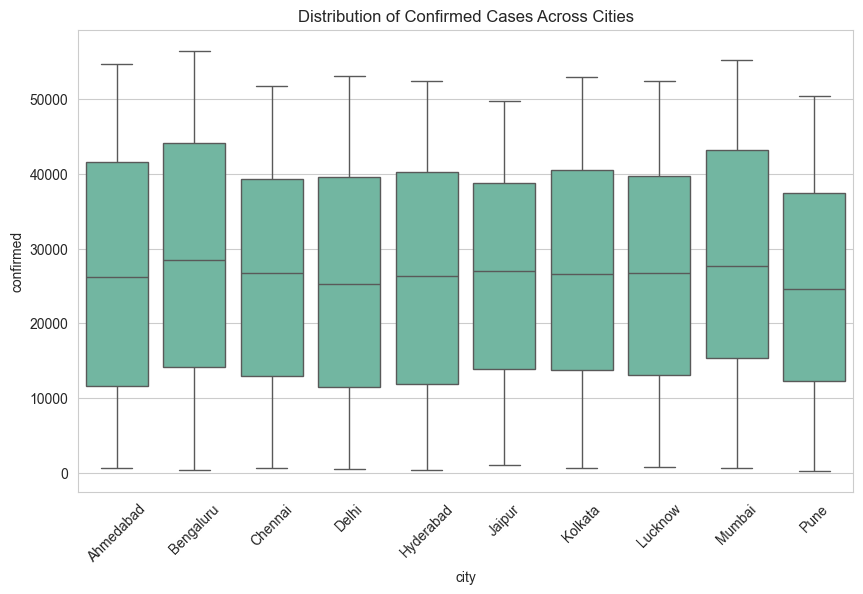

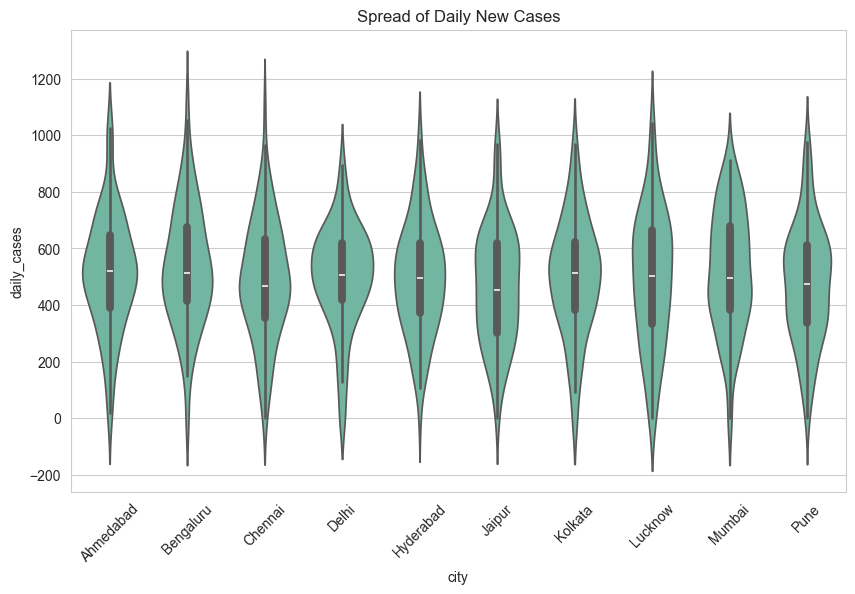

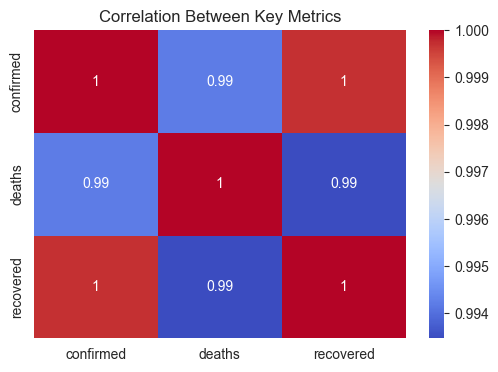

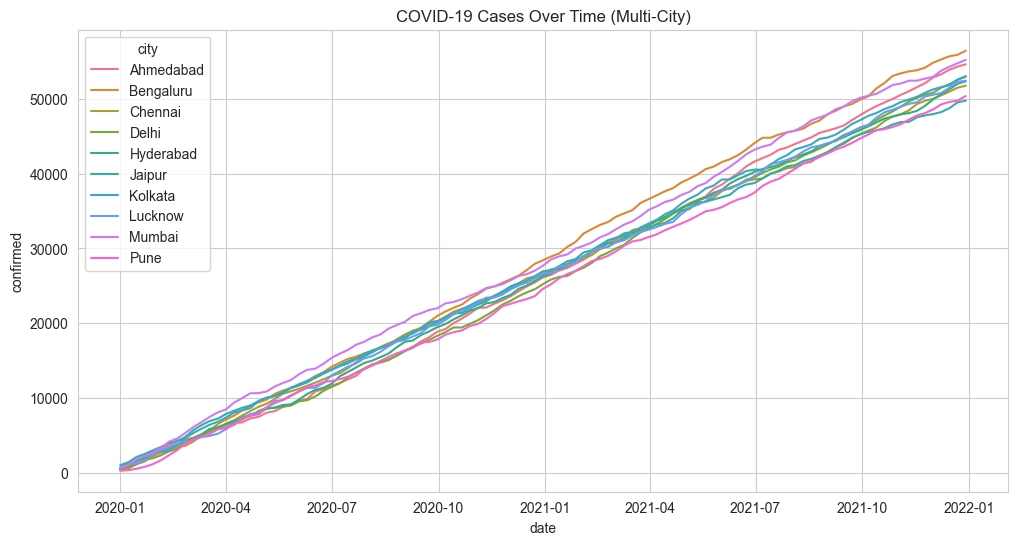

In [9]:
# Box Plot: Distribution of cases across cities
plt.figure(figsize=(10,6))
sns.boxplot(x='city', y='confirmed', data=city_data)
plt.title("Distribution of Confirmed Cases Across Cities")
plt.xticks(rotation=45)
plt.show()

# Violin Plot: Spread of daily new cases
plt.figure(figsize=(10,6))
sns.violinplot(x='city', y='daily_cases', data=city_data)
plt.title("Spread of Daily New Cases")
plt.xticks(rotation=45)
plt.show()

# Heatmap: Correlation
plt.figure(figsize=(6,4))
sns.heatmap(city_data[['confirmed','deaths','recovered']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Key Metrics")
plt.show()

# Trend Analysis: Multi-city comparison
plt.figure(figsize=(12,6))
sns.lineplot(x='date', y='confirmed', hue='city', data=city_data)
plt.title("COVID-19 Cases Over Time (Multi-City)")
plt.show()


## 📈 3. Interactive Visualizations (Plotly)


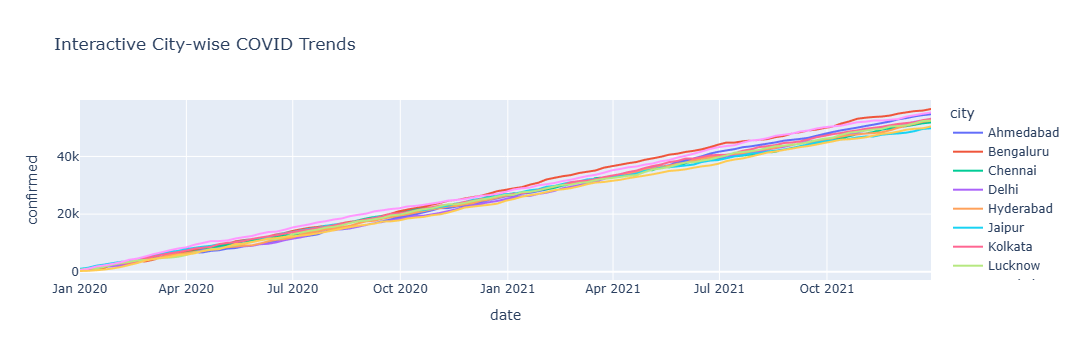

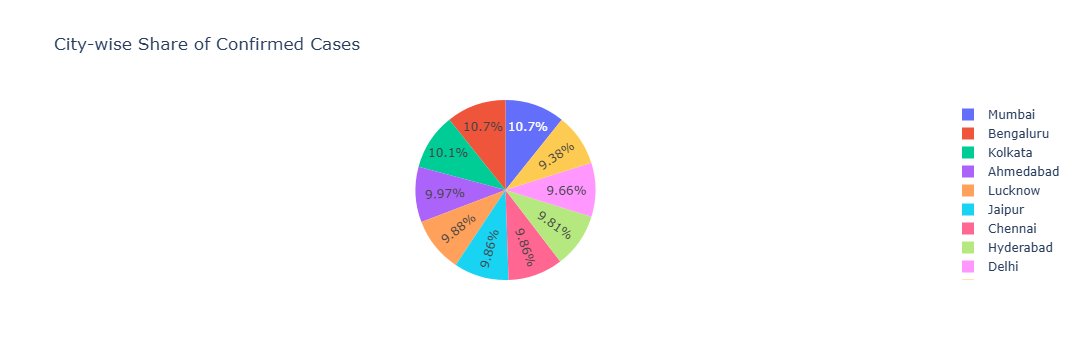

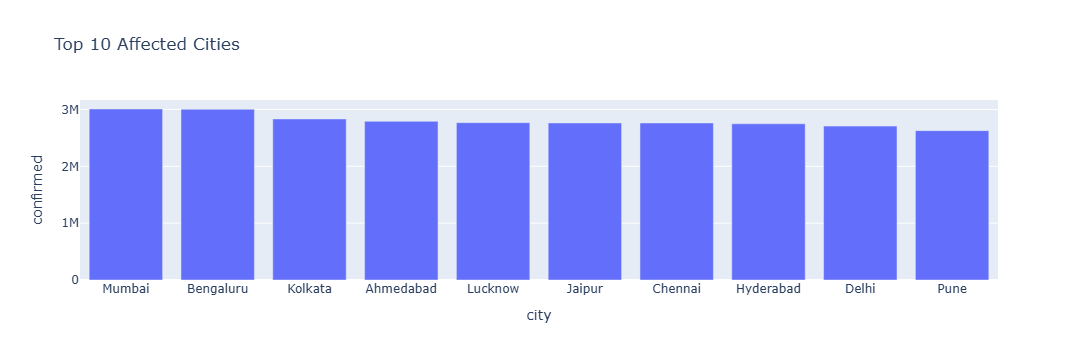

In [11]:
# Interactive Line Chart
fig = px.line(city_data, x="date", y="confirmed", color="city",
              title="Interactive City-wise COVID Trends")
fig.update_layout(hovermode="x unified")
fig.show()

# Pie Chart: Active vs Recovered vs Deaths
latest = city_data.groupby('city').sum(numeric_only=True).reset_index()
fig = px.pie(latest, values='confirmed', names='city',
             title="City-wise Share of Confirmed Cases")
fig.show()

# Bar Chart: Top affected cities
top_cities = latest.sort_values(by='confirmed', ascending=False).head(10)
fig = px.bar(top_cities, x='city', y='confirmed',
             title="Top 10 Affected Cities")
fig.show()


## 🗺️ 4. Geographic Visualization (Folium)


In [ ]:
# Create Folium Map
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)  # Center on India

marker_cluster = MarkerCluster().add_to(m)

for _, row in latest.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],  # Ensure dataset has lat/lon
        radius=row['confirmed']/1000,
        color='red',
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['city']}<br>Cases: {row['confirmed']}<br>Deaths: {row['deaths']}<br>Recovered: {row['recovered']}"
    ).add_to(marker_cluster)

m


## 🎛️ 5. Interactive Widgets (Bonus)


In [ ]:
# Dropdown to filter city
city_dropdown = widgets.Dropdown(options=city_data['city'].unique(), description="City:")
output = widgets.Output()

def update_plot(change):
    with output:
        output.clear_output()
        city = change['new']
        fig = px.line(city_data[city_data['city']==city], x="date", y="confirmed",
                      title=f"COVID Trend for {city}")
        fig.show()

city_dropdown.observe(update_plot, names='value')
display(city_dropdown, output)


<div style="
    background: linear-gradient(135deg, #141e30, #243b55);
    padding: 28px;
    border-radius: 18px;
    color: #f1f5f9;
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
    box-shadow: 0 10px 30px rgba(0,0,0,0.35);
    border: 1px solid rgba(255,255,255,0.08);
    backdrop-filter: blur(6px);
">

<h2 style="
    margin-bottom: 18px;
    font-size: 26px;
    letter-spacing: 0.5px;
">
✨ Final Insights & Conclusion
</h2>

<ul style="
    line-height: 1.9;
    font-size: 15.5px;
    padding-left: 20px;
    margin: 0;
">

<li>📊 <b>City-wise trends vary significantly</b>, with some regions showing rapid spikes while others follow smoother growth curves.</li>

<li>🔗 <b>Strong correlation observed</b> between confirmed and recovered cases, highlighting recovery progression alongside infection rates.</li>

<li>⚡ <b>Interactive dashboard</b> empowers users to explore data dynamically across cities and timelines.</li>

<li>🌍 <b>Geospatial visualization (Folium)</b> enhances understanding by clearly identifying hotspots and regional intensity.</li>

</ul>

<div style="
    margin-top: 20px;
    padding: 14px;
    border-radius: 12px;
    background: rgba(255,255,255,0.06);
    border-left: 4px solid #38bdf8;
">

<p style="margin: 0; font-size: 15.5px; line-height: 1.7;">
🚀 This notebook highlights how combining 
<b>Data Science</b>, <b>Interactive Visualization</b>, and 
<b>Geospatial Analysis</b> can produce a 
<b>modern, insightful, and decision-support COVID-19 dashboard</b>.
</p>

</div>

</div>